# Simple Model All Data

In [1]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

## Imports and Paths

In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import seaborn as sns

from esda.moran import Moran
from libpysal.weights import KNN
from esda.moran import Moran_Local
import folium
from scipy import stats
import networkx as nx
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "Code" else Path.cwd()

sys.path.append(str(PROJECT_ROOT / "Code"))
sys.path.append(str(PROJECT_ROOT / "Code" / "Data_Processing" / "Workfiles"))

from preprocessing_busdata import (
    aggregate_realtime_by_station,
    alpha_ilr_transform,
)

from thesis_core import (
    DATA_DIR,
    GTFS_DIR,
    load_static_gtfs,
    canonical_stations,
    build_station_meta,
    build_bus_station_edges,
    build_sar_weights,
    fit_sar_ilr,
    reconstruct_compositions,
)

In [3]:
# Final Specification
np.random.seed(36)

### Load the Static GTFS Data

In [4]:
# Load the static GTFS data from the CSV files.
stops, trips, stop_times, routes = load_static_gtfs()

# Build the network from the aligned GTFS data. Remove duplicates and normalize the IDs.
# Ensure that stops are assigned the respective parent station, i.e. the station that it is assigned to.
stops = canonical_stations(stops)
station_meta = build_station_meta(stops)

print(f"Stations with coordinates: {len(station_meta)}")

Stations with coordinates: 13179


### Load & Aggregate realtime data

In [5]:
# Create one composition per station aggregating over all available data (not per time bin).
bus_comp = aggregate_realtime_by_station(data_dir=DATA_DIR, stops_file=GTFS_DIR / "stops.txt", by_time_bin=False)

# Align the composition data with the static data available into one dataframe.
bus_comp = bus_comp.merge(station_meta[["station_id", "stop_name", "stop_lat", "stop_lon"]], on="station_id",
                          how="left", validate="many_to_one")

### ilr-Transform at Station Level

To illustrate why an alpha-ilr-transform is needed, quickly observe the share of zero entries for the different shares. The early component has almost 40% of its entries being zero, such that handling those is essential to the application.

In [6]:
zero_diag = pd.DataFrame({
    "early_zero": (bus_comp["early"] == 0),
    "on_time_zero": (bus_comp["on_time"] == 0),
    "delayed_zero": (bus_comp["delayed"] == 0),
})

zero_summary = zero_diag.mean().to_frame("share_zero")
zero_summary

,share_zero
early_zero,0.372973
on_time_zero,0.000802
delayed_zero,0.025031


In [7]:
# Set up the target and yield the alpha-ilr transformed data that can be directly plugged in.
Y = bus_comp[["early", "on_time", "delayed"]].to_numpy(float)
Z = alpha_ilr_transform(Y, alpha=0.2)

# Add the transformed data back into the main dataframe.
bus_comp[["ilr1", "ilr2"]] = Z

### Build the Bus Network from the Static Data

In [8]:
# Using the custom helper function, save the set of edges in the network in one unified dataframe.
edges_df = build_bus_station_edges(stops=stops, stop_times=stop_times, trips=trips, routes=routes,)
print(f"Network edges: {len(edges_df)}")

Network edges: 32702


### Restrict to connected stations

In [9]:
# Subset the composition data to only those stations that are connected, i.e. have at least one edge.
network_stations = pd.unique(edges_df[["from_station", "to_station"]].astype(str).values.ravel())
bus_comp_sar = (bus_comp.assign(station_id=lambda x: x["station_id"].astype(str))
                .query("station_id in @network_stations")
                .reset_index(drop=True))

stations = bus_comp_sar["station_id"].tolist()
print("Stations in SAR domain:", len(stations))

Stations in SAR domain: 10983


### Build the Adjacency Matrix

In [10]:
# Using the edges and the station list, we build the adjacency matrix and the row-standardized version of it.
A, W_ps, keep_idx = build_sar_weights(edges_df=edges_df, stations=stations)
print("Non-isolated stations:", len(keep_idx))

('WARNING: ', 2174, ' is an island (no neighbors)')
('WARNING: ', 2379, ' is an island (no neighbors)')
('WARNING: ', 2424, ' is an island (no neighbors)')
('WARNING: ', 5940, ' is an island (no neighbors)')
('WARNING: ', 6180, ' is an island (no neighbors)')
('WARNING: ', 10705, ' is an island (no neighbors)')
('WARNING: ', 10712, ' is an island (no neighbors)')
Non-isolated stations: 10976


## Baseline Model

### Fit the Baseline SAR model on the Entire Dataset

In [11]:
# Extract the ilr-transformed numeric target.
Z_sar = bus_comp_sar[["ilr1", "ilr2"]].to_numpy(float)

# Fit the SAR model as an intercept-only model (i.e. no covariates, only the spatial lag) and print the results.
models, fitted_Z, W_cent = fit_sar_ilr(Z=Z_sar, W_ps=W_ps, keep_idx=keep_idx,X=None)
for k, m in enumerate(models):
    print(f"\nILR{k+1}")
    print("rho:", m.rho)
    print("betas:", m.betas.flatten())


ILR1
rho: 0.5792000439940249
betas: [-1.02157312  0.57920004]

ILR2
rho: 0.5792000439940249
betas: [0.00654193 0.57920004]


### Backtransform the Output into Compositions

In [12]:
# Backtransform these compositions
Y_hat = reconstruct_compositions(fitted_Z=fitted_Z, bus_comp_grouped=bus_comp,
                                 bus_comp_sar=bus_comp_sar, keep_idx=keep_idx)

# Create a output table containing the station IDs as well as the output compositions as well as the residuals.
output_tab = bus_comp[["station_id"]].copy() # Station name
output_tab[["early_hat", "on_time_hat", "delayed_hat"]] = Y_hat # Fitted values
Y_full = bus_comp[["early", "on_time", "delayed"]].to_numpy(float) 
output_tab[["early_res", "on_time_res", "delayed_res"]] = Y_full - Y_hat # Residuals in compositional space

### Diagnostics on Residuals (Distribution and Q-Q Plot)

The diagnostics confirm that the residuals are approximately normally distributed confirming that the assumption is held.

[ILR1] JB p-value = 4.262e-31
[ILR2] JB p-value = 0


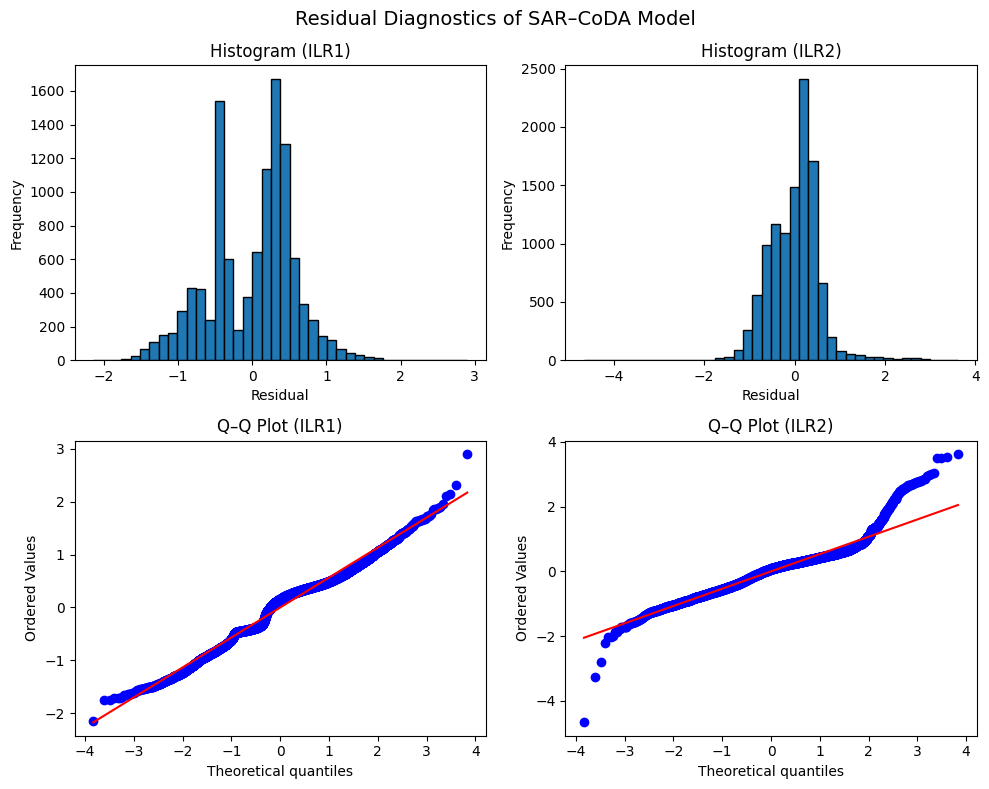

In [13]:
# Extract residuals in ilr-transformed space.
res_ilr_base = [m.u.flatten() for m in models]

# Set up two plots in the same figure
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Plot both the empirical distribution of the residuals as well as the corresponding Q-Q plot for each ilr-coordinate.
for k, r in enumerate(res_ilr_base):
    # --- Histogram (top row) ---
    axes[0, k].hist(r, bins=40, edgecolor="black")
    axes[0, k].set_title(f"Histogram (ILR{k+1})")
    axes[0, k].set_xlabel("Residual")
    axes[0, k].set_ylabel("Frequency")

    # --- Q-Q plot (bottom row) ---
    stats.probplot(r, dist="norm", plot=axes[1, k])
    axes[1, k].set_title(f"Q–Q Plot (ILR{k+1})")

    # Print Jarque-Bera test
    jb = stats.jarque_bera(r)
    print(f"[ILR{k+1}] JB p-value = {jb.pvalue:.4g}")

plt.suptitle("Residual Diagnostics of SAR–CoDA Model", fontsize=14)
plt.tight_layout()
plt.show()

### Residual Moran's I Global Baseline Model

The Residual Moran's I is calculated to get an understanding of how much spatial correlation remains in the residuals of the baseline model for each ilr-coordinate.

In [14]:
# Define the standard significance stars
def stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return ""

# Calculate Moran's I on the residuals and yield the p-values from a permutation test (999).
for k, r in enumerate(res_ilr_base):
    mi = Moran(r, W_cent, permutations=999)
    print(
        f"[ilr{k+1}] Moran's I = {mi.I:.4f}{stars(mi.p_sim)} "
        f"(p = {mi.p_sim:.4f})"
    )

[ilr1] Moran's I = 0.0354** (p = 0.0010)
[ilr2] Moran's I = 0.2430** (p = 0.0010)


## Centrality Augmented Model

### Calculate the centrality measures

In [15]:
# Create a NetworkX graph from the adjacency matrix.
G = nx.from_scipy_sparse_array(A)
n = len(stations)

# Calculate various centrality measures for each of the stations in the network and then combine them
# into a dataframe using list comprehensions to ensure correct ordering.
degree_raw = dict(G.degree())
degree_cent = nx.degree_centrality(G)
eig_cent = nx.eigenvector_centrality(G, max_iter=500)
bet_cent = nx.betweenness_centrality(G, k=500, seed=36, normalized=True)
pagerank = nx.pagerank(G, alpha=0.85)

cent_df = pd.DataFrame({
    "station_id": stations,
    "degree": [degree_raw[i] for i in range(n)],
    "degree_cent": [degree_cent[i] for i in range(n)],
    "eig_cent": [eig_cent[i] for i in range(n)],
    "bet_cent": [bet_cent[i] for i in range(n)],
    "pagerank": [pagerank[i] for i in range(n)]})

### Correlation Table of Centrality Measures and VIF to observe Multicollinearity and do Variable Selection

In [16]:
# Calculate the correlation matrix of the differenc centrality measures.
corr_table = cent_df[["degree", "degree_cent", "eig_cent", "bet_cent", "pagerank"]].corr()

print("Centrality correlation matrix:")
print(corr_table.round(3))

# Calculate the Variance Inflation Factor for all centrality measures.
X_vif = cent_df[["degree", "degree_cent", "eig_cent", "bet_cent", "pagerank"]].copy()
# To regress the variables on all other variables, we need to add the intercept term to the dataframe.
X_vif["const"] = 1
vif_df = pd.DataFrame({"variable": X_vif.columns,
                       "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]})
# After regressing, we can remove the intercept again.
vif_df = vif_df[vif_df["variable"] != "const"]

print("\nVariance Inflation Factors:")
print(vif_df.round(3))

Centrality correlation matrix:
             degree  degree_cent  eig_cent  bet_cent  pagerank
degree        1.000        1.000     0.172     0.278     0.892
degree_cent   1.000        1.000     0.172     0.278     0.892
eig_cent      0.172        0.172     1.000     0.001     0.088
bet_cent      0.278        0.278     0.001     1.000     0.266
pagerank      0.892        0.892     0.088     0.266     1.000

Variance Inflation Factors:
      variable    VIF
0       degree    inf
1  degree_cent    inf
2     eig_cent  1.055
3     bet_cent  1.088
4     pagerank  5.016


### Fit the Centrality-Augmented SAR Model

In [17]:
# Ensure that the eigenvector centrality and betweenness centrality are on the same scale by standardizing them.
scaler = StandardScaler()
cent_df[["eig_cent", "bet_cent"]] = scaler.fit_transform(
    cent_df[["eig_cent", "bet_cent"]]
)

# Add the centrality measures into the main dataframe and then fit the SAR model with these additional covariates.
bus_comp = bus_comp.merge(cent_df[["station_id", "degree", "eig_cent", "bet_cent"]], on="station_id",
                          how="left",validate="one_to_one")
bus_comp[["degree", "eig_cent", "bet_cent"]] = (bus_comp[["degree", "eig_cent", "bet_cent"]].fillna(0.0))
X_cent = bus_comp[["bet_cent", "eig_cent"]].to_numpy(float)

models_cent, fitted_Z_cent, W_cent = fit_sar_ilr(Z=Z, W_ps=W_ps, keep_idx=keep_idx, X=X_cent)
xnames = ["const", "bet_cent", "eig_cent"]

# Produce the results and estimated coefficients.
for k, m in enumerate(models_cent):
    print(f"\n=== ILR{k+1} ===")
    print(f"rho: {m.rho:.3f}")

    print("Coefficients:")
    for name, coef, (z, p) in zip(xnames, m.betas.flatten(), m.z_stat):
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        print(f"{name:12s} {coef: .4f}   z = {z: .3f}   p = {p: .4g} {sig}")


=== ILR1 ===
rho: 0.479
Coefficients:
const        -1.2354   z = -56.551   p =  0 ***
bet_cent      0.0273   z =  4.103   p =  4.082e-05 ***
eig_cent      0.0037   z =  0.559   p =  0.5762 

=== ILR2 ===
rho: 0.491
Coefficients:
const         0.0180   z =  2.510   p =  0.01209 *
bet_cent      0.0072   z =  0.999   p =  0.3176 
eig_cent      0.0320   z =  4.482   p =  7.41e-06 ***


### Convert the estimated coefficients from the ilr-transformed space to the clr-transformed space

To make the coefficients interpretable based on the geometric mean, the coefficients are transformed into the clr-transformed space using the log-contrast matrix.

In [18]:
# Set up the log-contrast matrix for transforming the ilr coefficients into clr coefficients.
H = np.array([
    [1/np.sqrt(2), -1/np.sqrt(2), 0],
    [1/np.sqrt(6),  1/np.sqrt(6), -2/np.sqrt(6)]
])

# Build a helper function that performs the transform.
def ilr_to_clr(beta_ilr):
    return H.T @ beta_ilr

# Define the names of the parts for the output.
parts = ["early","on_time","delayed"]

for j, name in enumerate(xnames):
    # Collect the ilr coefficients.
    beta_ilr = np.array([
        models_cent[0].betas.flatten()[j],
        models_cent[1].betas.flatten()[j]
    ])

    # Transform into ilr
    beta_clr = ilr_to_clr(beta_ilr)

    # print(f"\n{name}")
    # print("betas_ilr   :", beta_ilr)
    # print("betas_clr :", beta_clr)

    # Calculate the covariance matrix of the ilr coefficients from the variance matrices of the model.
    cov_ilr = np.diag([
        models_cent[0].vm[j, j],
        models_cent[1].vm[j, j]
    ])

    # Transform into clr and yield the standard error, z-values and p-values and output the significance for
    # each of the coefficients.
    cov_clr = H.T @ cov_ilr @ H
    se_clr = np.sqrt(np.diag(cov_clr))
    z_clr = beta_clr / se_clr
    p_clr = 2 * (1 - stats.norm.cdf(np.abs(z_clr)))

    # Output the results in a consistent format.
    print(f"\n{name}:")
    for part, b, se, p in zip(parts, beta_clr, se_clr, p_clr):
        print(f"{part:10s}: beta={b: .4f}, SE={se:.4f}, p={p:.4f}")


const:
early     : beta=-0.8662, SE=0.0157, p=0.0000
on_time   : beta= 0.8809, SE=0.0157, p=0.0000
delayed   : beta=-0.0147, SE=0.0058, p=0.0121

bet_cent:
early     : beta= 0.0223, SE=0.0055, p=0.0001
on_time   : beta=-0.0164, SE=0.0055, p=0.0031
delayed   : beta=-0.0058, SE=0.0058, p=0.3176

eig_cent:
early     : beta= 0.0157, SE=0.0055, p=0.0045
on_time   : beta= 0.0105, SE=0.0055, p=0.0590
delayed   : beta=-0.0262, SE=0.0058, p=0.0000


### Residual Moran's I for the Augmented Model

In [19]:
# Yield the residuals for the centrality augmented model.
res_ilr_cent = [m.u.flatten() for m in models_cent]

for k, r in enumerate(res_ilr_cent):
    mi = Moran(r, W_cent, permutations=999)
    print(f"[CENT ILR{k+1}] Moran’s I = {mi.I:.4f}, p = {mi.p_sim:.4f}")

# Backtransform the model's outputs into the compositional space.
Y_hat_cent = reconstruct_compositions(fitted_Z=fitted_Z_cent, bus_comp_grouped=bus_comp,
                                      bus_comp_sar=bus_comp_sar, keep_idx=keep_idx)
output_cent = bus_comp[["station_id"]].copy()
output_cent[["early_hat","on_time_hat","delayed_hat"]] = Y_hat_cent

[CENT ILR1] Moran’s I = -0.0647, p = 0.0010
[CENT ILR2] Moran’s I = -0.0666, p = 0.0010


### Visualizations of Baseline and Centrality Prediction Fit

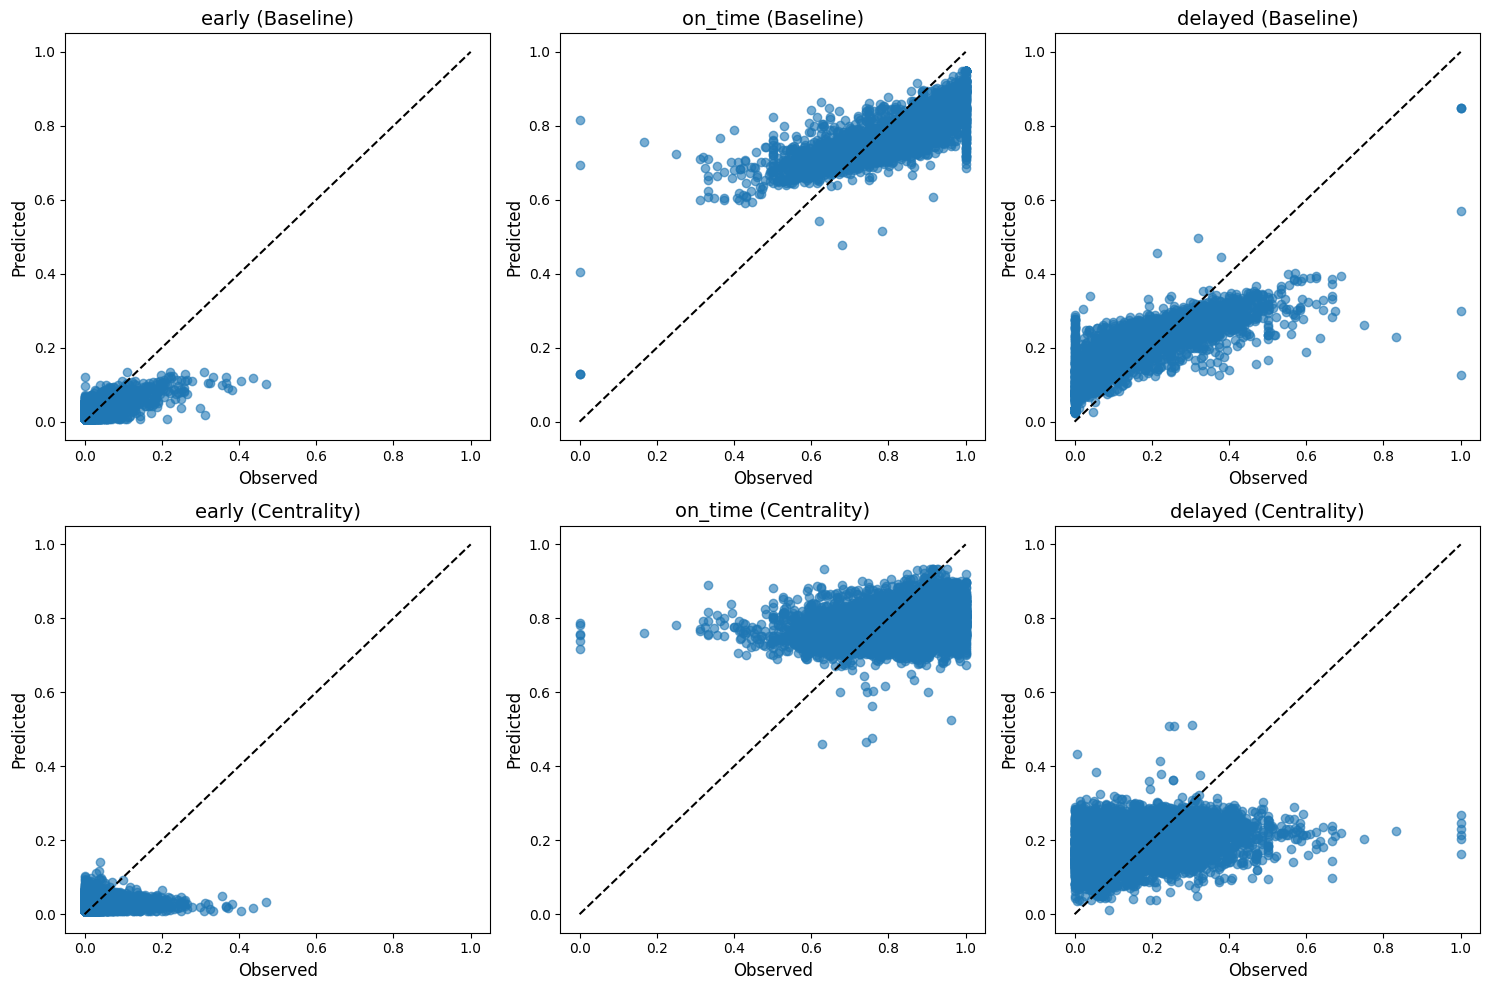

In [20]:
# Set up the subplots for visualization.
fig, axes = plt.subplots(2, 3, figsize=(15,10))

for i, p in enumerate(parts):

    # Plot the fitted values vs. the true values of baseline model on the top row.
    axes[0, i].scatter(bus_comp[p], output_tab[f"{p}_hat"], alpha=0.6)
    axes[0, i].plot([0,1],[0,1], color="black", linestyle="--")
    axes[0, i].set_title(f"{p} (Baseline)", fontsize=14)
    axes[0, i].set_xlabel("Observed", fontsize=12)
    axes[0, i].set_ylabel("Predicted", fontsize=12)

    # Plot the fitted values vs. the true values of centrality augmented model on the top row.
    axes[1, i].scatter(bus_comp[p], output_cent[f"{p}_hat"], alpha=0.6)
    axes[1, i].plot([0,1],[0,1], color="black", linestyle="--")
    axes[1, i].set_title(f"{p} (Centrality)", fontsize=14)
    axes[1, i].set_xlabel("Observed", fontsize=12)
    axes[1, i].set_ylabel("Predicted", fontsize=12)

plt.tight_layout()

plt.show()

### Visualize Fitted vs. True Delayed Share for Centrality Model

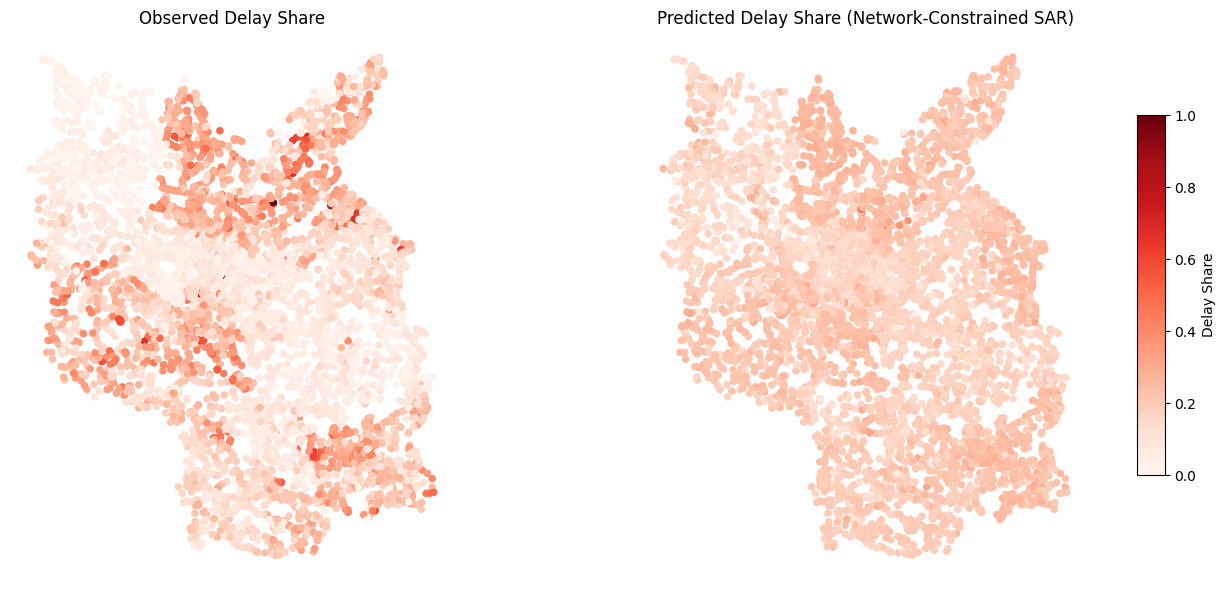

Observed variance: 0.012948875740290758
Predicted variance: 0.00213194921384057
Observed mean: 0.13663452128545453
Predicted mean: 0.18237393461884455


In [21]:
# Create a geodataframe with the locations of each station and the main dataframe.
gdf = gpd.GeoDataFrame(bus_comp, geometry=gpd.points_from_xy(bus_comp["stop_lon"], bus_comp["stop_lat"]), crs="EPSG:4326")
# Add the predicted delay share
gdf["delayed_hat"] = output_cent["delayed_hat"]

# Set up the subplots.
fig, axes = plt.subplots(1,2, figsize=(14,6))

# Define the shared colour range.
vmin = min(gdf["delayed"].min(), gdf["delayed_hat"].min())
vmax = max(gdf["delayed"].max(), gdf["delayed_hat"].max())

# Add the observed and fitted delay shares to the geodataframe plot.
gdf.plot(column="delayed", cmap="Reds", vmin=vmin, vmax=vmax, markersize=20, ax=axes[0])
axes[0].set_title("Observed Delay Share")
axes[0].axis("off")
gdf.plot(column="delayed_hat", cmap="Reds", vmin=vmin, vmax=vmax, markersize=20, ax=axes[1])
axes[1].set_title("Predicted Delay Share (Network-Constrained SAR)")
axes[1].axis("off")

# Create a colorbar object.
sm = plt.cm.ScalarMappable(cmap="Reds",norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []

# Add the custom colorbar to the right of the subplots.
cax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
fig.colorbar(sm, cax=cax, label="Delay Share")

plt.tight_layout()
plt.show()

# To see the smoothing a little more clearly, the mean and variance of the delay share are also produced.
print("Observed variance:", bus_comp["delayed"].var())
print("Predicted variance:", output_cent["delayed_hat"].var())
print("Observed mean:", bus_comp["delayed"].mean())
print("Predicted mean:", output_cent["delayed_hat"].mean())

### Model Comparison

In [22]:
# Compare the estimated spatial lag parameter.
for k in range(2):
    print(f"\nILR{k+1}")
    print("Baseline rho:", round(models[k].rho, 3))
    print("Centrality rho:", round(models_cent[k].rho, 3))


ILR1
Baseline rho: 0.579
Centrality rho: 0.479

ILR2
Baseline rho: 0.579
Centrality rho: 0.491


In [23]:
# Compare the AIC across both models
aics = []
for k in range(2):
    aics.append({
        "ilr": f"ilr{k+1}",
        # Calculate the AIC for each ilr-coordinate
        "AIC Baseline": models[k].aic,
        "AIC Centrality": models_cent[k].aic,
    })

pd.DataFrame(aics)

,ilr,AIC Baseline,AIC Centrality
0,ilr1,20470.367941,24209.435032
1,ilr2,19469.623390,25843.022133


In [24]:
# Pseudo-R² comparison

# Define a helper that calculates the Pseudo-R2.
def pseudo_r2(m):
    y = m.y.flatten()
    yhat = m.predy.flatten()
    return np.corrcoef(y, yhat)[0,1]**2

PsRSq = []
for k in range(2):
    PsRSq.append({
        "ilr": f"ilr{k+1}",
        "Pseudo-R2 Baseline": pseudo_r2(models[k]),
        "Pseudo-R2 Centrality": pseudo_r2(models_cent[k]),
    })

pd.DataFrame(PsRSq)

,ilr,Pseudo-R2 Baseline,Pseudo-R2 Centrality
0,ilr1,0.584819,0.319214
1,ilr2,0.741251,0.335049


In [25]:
for k in range(2):
    z_base, p_base = models[k].z_stat[-1]
    z_cent, p_cent = models_cent[k].z_stat[-1]

    print(f"\nILR{k+1}")
    print(f"Baseline rho:   {models[k].rho:.3f}{stars(p_base)}  (z={z_base:.3f}, p={p_base:.4g})")
    print(f"Centrality rho: {models_cent[k].rho:.3f}{stars(p_cent)}  (z={z_cent:.3f}, p={p_cent:.4g})")



ILR1
Baseline rho:   0.579***  (z=74.244, p=0)
Centrality rho: 0.479***  (z=54.518, p=0)

ILR2
Baseline rho:   0.579***  (z=74.244, p=0)
Centrality rho: 0.491***  (z=56.615, p=0)


## LISA analysis

In the following, the pain-points in the network are identified using the LISA labeling based on the residual structure each model produces.

In [26]:
# Subset the relevant stations for the LISA analysis.
df_cent = bus_comp_sar.iloc[keep_idx].copy().reset_index(drop=True)

# Ensure the coordinates are numeric for the spatial weights and the LISA analysis.
df_cent["stop_lat"] = pd.to_numeric(df_cent["stop_lat"], errors="coerce")
df_cent["stop_lon"] = pd.to_numeric(df_cent["stop_lon"], errors="coerce")

# Select which ilr-coordinate to analyze.
k = 0  # 0=ilr1, 1=ilr2

# For each component, extract the residuals and calculate the local Moran's I using a permutation test.
r_base = res_ilr_base[k]
r_cent = res_ilr_cent[k]
lisa_base = Moran_Local(r_base, W_cent, permutations=999)
lisa_cent = Moran_Local(r_cent, W_cent, permutations=999)

# Extract the significant nodes for both models that ar in the Low-High cluster.
df_cent["LH_base"] = ((lisa_base.q == 2) & (lisa_base.p_sim < 0.05))
df_cent["LH_cent"] = ((lisa_cent.q == 2) & (lisa_cent.p_sim < 0.05))

print("Low–High stations (baseline):", df_cent["LH_base"].sum())
print("Low–High stations (centrality):", df_cent["LH_cent"].sum())

Low–High stations (baseline): 301
Low–High stations (centrality): 325


The empicial shock magnitude across the LH-clusters that is observed in the VBB bus network is analyzed, for later usage as a benchmark/calibration in simulation settings.

In [27]:
# Choose which ilr-coordinate to focus on.
k = 1  # ILR2
u = res_ilr_cent[k]
# Compute the neighborhood mean of the residuals with the row-standardized weights matrix.
u_lag = W_cent.sparse @ u
# Standardize to get a relative measure of the shock.
sigma_u = u.std()
# Calculate the dip
df_cent["dip_relative"] = (u_lag - u) / sigma_u

# Only look at LH-clusters.
lh_mask = ((lisa_cent.q == 2) & (lisa_cent.p_sim < 0.05))
lh_dips = df_cent.loc[lh_mask, "dip_relative"]

# Print distributional characteristics of the relative dip for the LH-clusters.
print("Number of LH stations:", lh_mask.sum())
print("Mean relative dip:", lh_dips.mean())
print("Median relative dip:", lh_dips.median())
print("75th percentile:", lh_dips.quantile(0.75))
print("90th percentile:", lh_dips.quantile(0.90))

Number of LH stations: 325
Mean relative dip: 1.3448110253139356
Median relative dip: 1.5731127962360674
75th percentile: 2.2373956724173665
90th percentile: 2.9737101078229013


### Pain-Points with Custom Severity Ranking

In [28]:
def build_hybrid_df(bus_comp_sar, keep_idx, residuals, lisa, model_label, ilr_label):
    """
    Build hybrid LISA–residual dataframe for one ILR component.
    """

    # Extract the dataframe.
    df = bus_comp_sar.iloc[keep_idx].copy().reset_index(drop=True)

    # Extract the residuals, local Moran's I, p-values and cluster labels from the LISA analysis.
    df["residual_ilr"] = residuals
    df["local_I"] = lisa.Is
    df["p_value"] = lisa.p_sim
    df["cluster"] = lisa.q

    # Filter for only significant LH-clusters.
    df["is_significant"] = df["p_value"] < 0.05
    df["is_problem"] = df["cluster"] == 2 

    # Calculate the hybrid score as the significant LH-clusters with the local Moran's I 
    # multiplied by the absolute residual.
    df["hybrid_score"] = (
        df["is_significant"].astype(int)
        * df["is_problem"].astype(int)
        * np.abs(df["local_I"])
        * np.abs(df["residual_ilr"])
    )

    # Add model and ilr labels.
    df["model"] = model_label
    df["ilr"] = ilr_label

    # Sort the stations by hybrid score and print the top 10 most problematic stations according to the hybrid score.
    return df[[
        "station_id",
        "stop_name",
        "stop_lat",
        "stop_lon",
        "residual_ilr",
        "local_I",
        "p_value",
        "model",
        "ilr",
        "hybrid_score"
    ]].sort_values("hybrid_score", ascending=False)

After building a custom helper function, the custom serverity rankings for each ilr-coordinate and model can easily be produced.

In [29]:
# ILR1
df_hybrid_ilr1 = build_hybrid_df(
    bus_comp_sar=bus_comp_sar,
    keep_idx=keep_idx,
    residuals=res_ilr_cent[0],
    lisa=lisa_cent,
    model_label="Centrality",
    ilr_label="ilr1",
)

# ILR2
df_hybrid_ilr2 = build_hybrid_df(
    bus_comp_sar=bus_comp_sar,
    keep_idx=keep_idx,
    residuals=res_ilr_cent[1],
    lisa=lisa_cent,
    model_label="Centrality",
    ilr_label="ilr2",
)

df_hybrid_ilr1.head(10)

,station_id,stop_name,stop_lat,stop_lon,residual_ilr,local_I,p_value,model,ilr,hybrid_score
10353,900445309,"Dissen, Nord",51.827287,14.283860,-1.890045,-7.664872,0.001,Centrality,ilr1,14.486952
7608,900315337,"Langennaundorf, B 101",51.605184,13.340854,-1.920004,-6.742826,0.002,Centrality,ilr1,12.946250
35,900003156,Ottostr. (Berlin),52.524645,13.334485,-1.892843,-5.554146,0.002,Centrality,ilr1,10.513129
10616,900446047,Mulknitz,51.767458,14.599222,-1.762872,-5.817350,0.001,Centrality,ilr1,10.255245
3493,900205323,"Heiligengrabe, Pritzwalker Str.",53.139053,12.344873,-1.775464,-4.839662,0.003,Centrality,ilr1,8.592644
10408,900445458,"Cottbus, Telering",51.701064,14.365651,-1.632446,-5.202250,0.006,Centrality,ilr1,8.492393
9391,900415043,Dabern,51.710296,13.671800,-1.577642,-5.370590,0.001,Centrality,ilr1,8.472867
10284,900445100,"Forst, Krematorium",51.758400,14.647795,-1.730829,-4.889177,0.004,Centrality,ilr1,8.462330
47,900003301,Katharina-Paulus-Str. (Berlin),52.522512,13.366585,-1.759090,-4.793728,0.003,Centrality,ilr1,8.432597
66,900005207,Philharmonie Süd (Berlin),52.508772,13.369929,-1.758241,-4.340435,0.003,Centrality,ilr1,7.631532


Next, the pain points and their severity is plotted.

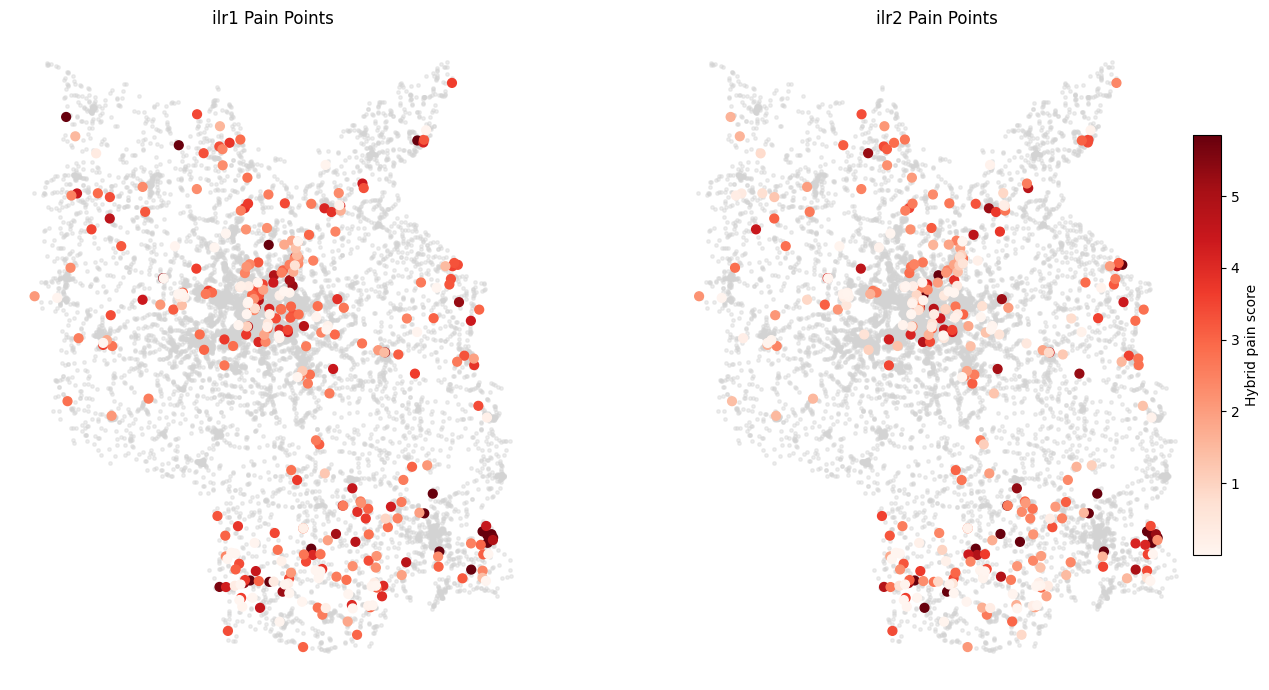

In [30]:
# Set up the subplots for the visualization.
fig, axes = plt.subplots(1, 2, figsize=(14,7))

# Loop over the pain points for both ilr-coordinates.
for ax, df, title in zip(axes, [df_hybrid_ilr1, df_hybrid_ilr2], ["ilr1 Pain Points", "ilr2 Pain Points"]):

    # Filter for significant LH-clusters with a severity score.
    pain = df[
        (df["p_value"] < 0.05) &
        (df["hybrid_score"] > 0)
    ].copy()

    # Create two geodataframes, one for all stations and one for the pain points, to plot them on the map.
    gdf_all = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.stop_lon, df.stop_lat),crs="EPSG:4326")
    gdf_pain = gpd.GeoDataFrame(pain, geometry=gpd.points_from_xy(pain.stop_lon, pain.stop_lat), crs="EPSG:4326")

    # Create the colour scale based on the hybrid score, cutting off outliers.
    norm = Normalize(vmin=gdf_pain["hybrid_score"].min(), vmax=gdf_pain["hybrid_score"].quantile(0.95))

    # Plot all stations as light grey points and overlay the pain points with a colour scale based on the hybrid score.
    gdf_all.plot(ax=ax, color="lightgrey", markersize=6, alpha=0.4)
    gdf_pain.plot(ax=ax, column="hybrid_score", cmap="Reds", markersize=40, norm=norm, legend=False)

    ax.set_title(title)
    ax.set_axis_off()

# Create a shared colourbar and place it next to the maps.
sm = ScalarMappable(norm=norm, cmap="Reds")
sm._A = []
cax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
fig.colorbar(sm, cax=cax, label="Hybrid pain score")

plt.tight_layout()

plt.show()

# Models for different Time-Bins

In [31]:
# Build a global graph from the static adjacency that is valid across all time bins.
edges_df = build_bus_station_edges(stops, stop_times, trips, routes)
network_stations = pd.unique(edges_df[["from_station","to_station"]].astype(str).values.ravel())

# Set up the adjacency matrix and the row-standardized version of it for the full set of stations.
stations_all = network_stations.tolist()
A_all, W_ps_all, keep_idx_all = build_sar_weights(edges_df, stations_all)
G = nx.from_scipy_sparse_array(A_all)

# Calculate the degree, eigenvector centrality and betweenness centrality 
# for each station in the network and combine them into a dataframe.
degree = np.array([d for _, d in G.degree()])
eig_cent = np.array(list(nx.eigenvector_centrality(G, max_iter=500).values()))
bet_cent = np.array(list(nx.betweenness_centrality(G, k=500, seed=36).values()))

# dataframe indexed by station_id
cent_df = pd.DataFrame({
    "station_id": stations_all,
    "degree": degree,
    "eig_cent": eig_cent,
    "bet_cent": bet_cent,
})

# Again, the centrality measures are standardized.
scaler = StandardScaler()
cent_df[["eig_cent","bet_cent"]] = scaler.fit_transform(
    cent_df[["eig_cent","bet_cent"]]
)

### Fit both models for each time bin.

In [32]:
# Define the list of time bins.
TIME_BINS = ["0-6","6-12","12-18","18-24"]

# Build the compositions for each time bin.
bus_comp_tb = aggregate_realtime_by_station(
    data_dir=DATA_DIR,
    stops_file=GTFS_DIR / "stops.txt",
    by_time_bin=True
)

# Add station metadata.
bus_comp_tb = bus_comp_tb.merge(
    station_meta[["station_id","stop_name","stop_lat","stop_lon"]],
    on="station_id",
    how="left",
    validate="many_to_one"
)

# Initialize a dictionary to store the results for each time bin.
results = {}   # store per time bin outputs

for tb in TIME_BINS:
    # Subset the data for the current time bin.
    df_bin = bus_comp_tb[bus_comp_tb["time_bin"] == tb].copy()

    # Restict to stations in the static network to ensure comparability.
    df_bin = (
        df_bin.assign(station_id=lambda x: x["station_id"].astype(str))
              .query("station_id in @network_stations")
              .reset_index(drop=True)
    )

    # Attach the centrality measures.
    df_bin = df_bin.merge(cent_df[["station_id","eig_cent","bet_cent"]], on="station_id",
                          how="left", validate="many_to_one")

    # # fill stations without centrality (should be rare)
    # df_bin[["eig_cent","bet_cent"]] = df_bin[["eig_cent","bet_cent"]].fillna(0.0)

    # For followability produce an output of the timebin and stations included.
    print(f"\nTime bin {tb}")
    print("Stations:", len(df_bin))

    # Yield the alpha-ilr transformed compositions for this time bin and add them to the dataframe.
    Z_bin = alpha_ilr_transform(df_bin[["early","on_time","delayed"]].to_numpy(float))
    df_bin[["ilr1","ilr2"]] = Z_bin

    # Set up the adjacency matrix and row-standardized weights for the stations in this time bin.
    stations_bin = df_bin["station_id"].tolist()
    A_bin, W_ps_bin, keep_idx_bin = build_sar_weights(edges_df, stations_bin)

    # Fit the baseline SAR model.
    Z_sar_bin = df_bin[["ilr1","ilr2"]].to_numpy(float)
    # baseline (intercept-only)
    models_base, fitted_Z_base, W_cent_bin = fit_sar_ilr(Z=Z_sar_bin, W_ps=W_ps_bin, 
                                                         keep_idx=keep_idx_bin, X=None)

    # Create the design matrix for the centrality-augmented model and fit the model.
    X_cent_bin = df_bin[["bet_cent","eig_cent"]].to_numpy(float)
    models_cent, fitted_Z_cent, _ = fit_sar_ilr(Z=Z_sar_bin, W_ps=W_ps_bin,
                                                keep_idx=keep_idx_bin, X=X_cent_bin)

    # Finally, also store the results for this time bin in the results dictionary for later use.
    results[tb] = {
        "df": df_bin,
        "A": A_bin,
        "W_ps": W_ps_bin,
        "W_cent": W_cent_bin,
        "keep_idx": keep_idx_bin,

        "models_base": models_base,
        "fitted_Z_base": fitted_Z_base,

        "models_cent": models_cent,
        "fitted_Z_cent": fitted_Z_cent,
        "N": len(df_bin),
    }

    # Produce an overview of the estimated parameters.
    print(f"\nResults for Time bin {tb}")
    for k in range(2):
        for label, m in [("Baseline", models_base[k]), ("Centrality", models_cent[k])]:
            z_rho, p_rho = m.z_stat[-1]
            print(
                f"{label} ILR{k+1}: "
                f"rho={m.rho:.3f}{stars(p_rho)} "
                f"(z={z_rho:.3f}, p={p_rho:.4g})"
            )
    xnames = ["const","bet_cent","eig_cent"]
    for k, m in enumerate(models_cent):
        print(f"\n[Centrality] ILR{k+1}")
        for name, coef, (z,p) in zip(
            xnames,
            m.betas.flatten(),
            m.z_stat
        ):
            print(f"{name:12s} {coef: .3f}  z={z: .2f}  p={p:.4g} {stars(p)}")


Time bin 0-6
Stations: 9339
('WARNING: ', 2123, ' is an island (no neighbors)')
('WARNING: ', 2327, ' is an island (no neighbors)')
('WARNING: ', 2372, ' is an island (no neighbors)')
('WARNING: ', 5578, ' is an island (no neighbors)')
('WARNING: ', 7509, ' is an island (no neighbors)')
('WARNING: ', 8193, ' is an island (no neighbors)')
('WARNING: ', 9086, ' is an island (no neighbors)')
('WARNING: ', 9121, ' is an island (no neighbors)')
('WARNING: ', 9122, ' is an island (no neighbors)')
('WARNING: ', 9154, ' is an island (no neighbors)')
('WARNING: ', 9192, ' is an island (no neighbors)')
('WARNING: ', 9233, ' is an island (no neighbors)')
('WARNING: ', 9242, ' is an island (no neighbors)')

Results for Time bin 0-6
Baseline ILR1: rho=0.609*** (z=76.815, p=0)
Centrality ILR1: rho=0.609*** (z=76.916, p=0)
Baseline ILR2: rho=0.609*** (z=76.815, p=0)
Centrality ILR2: rho=0.609*** (z=76.894, p=0)

[Centrality] ILR1
const        -1.264  z=-26.94  p=8.083e-160 ***
bet_cent      0.019  z

### Visualize the results for the different time bins.


Results for time bin 0-6


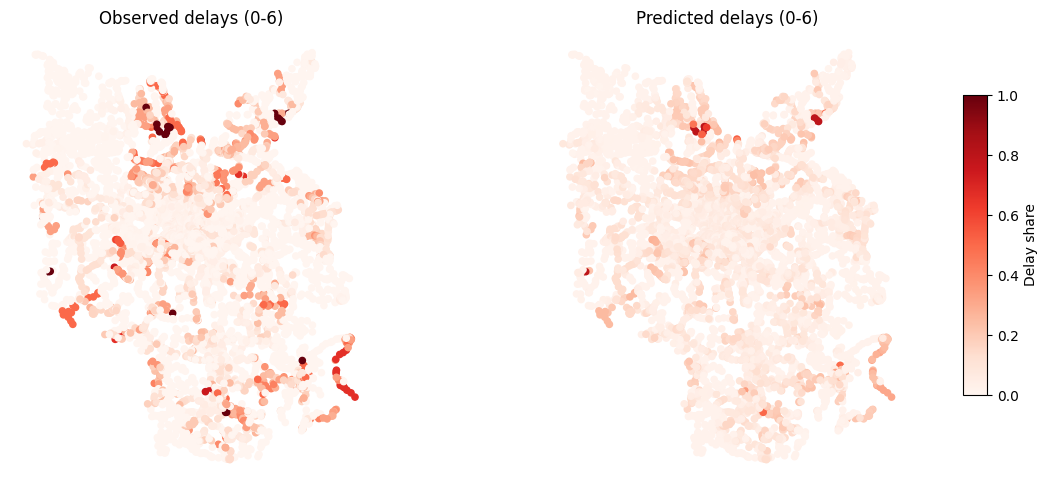


Results for time bin 6-12


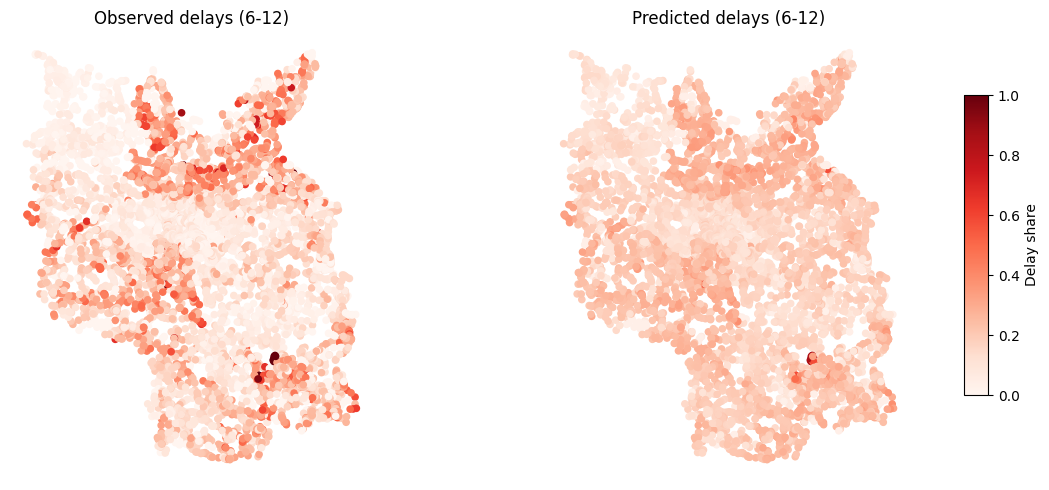


Results for time bin 12-18


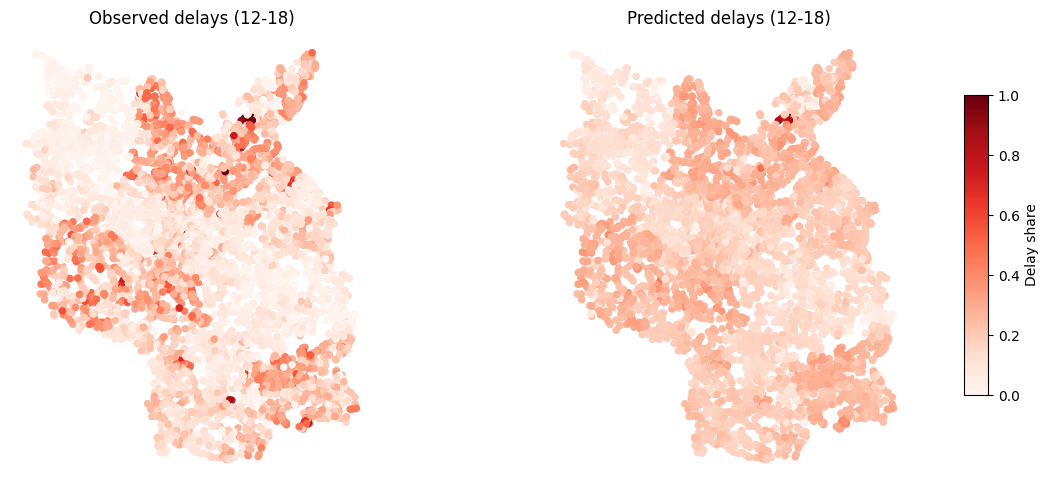


Results for time bin 18-24


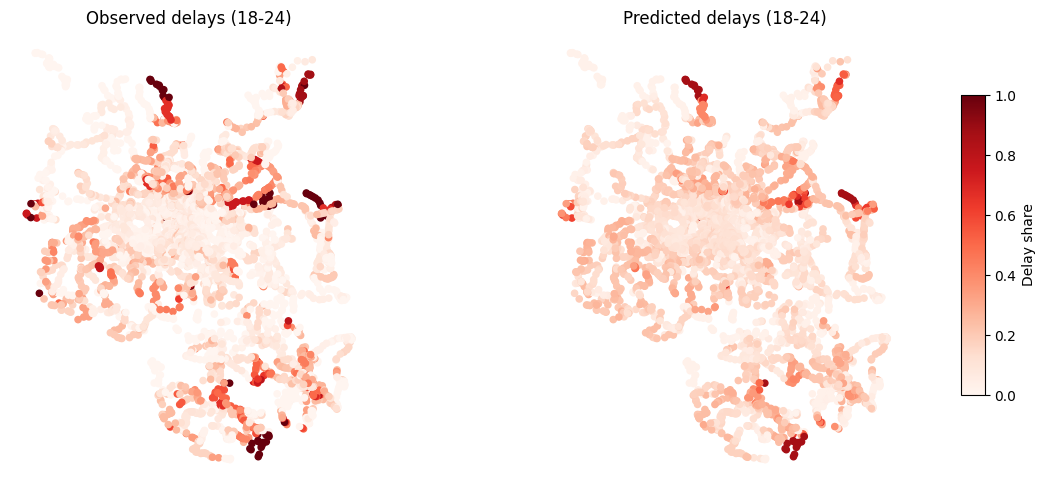

In [33]:
timebin_metrics = []

for tb, res in results.items():

    # Extract the relevant data for this time bin from the results dictionary.
    df_bin = res["df"]
    keep_idx = res["keep_idx"]
    fitted_Z_base = res["fitted_Z_base"]
    fitted_Z_cent = res["fitted_Z_cent"]

    print(f"\nResults for time bin {tb}")

    # Build the compositions for both the centrality augmented model by backtransforming the fitted values.
    Y_hat_cent = reconstruct_compositions(
        fitted_Z=fitted_Z_cent,
        bus_comp_grouped=df_bin,
        bus_comp_sar=df_bin,
        keep_idx=keep_idx
    )
    Y_obs = df_bin[["early","on_time","delayed"]].to_numpy(float)

    # Create the delayed share predictions for the centrality model.
    gdf = gpd.GeoDataFrame(
        df_bin,
        geometry=gpd.points_from_xy(df_bin["stop_lon"], df_bin["stop_lat"]),
        crs="EPSG:4326"
    )
    gdf["delayed_hat"] = Y_hat_cent[:,2]

    # Set up the colour range.
    vmin = min(gdf["delayed"].min(), gdf["delayed_hat"].min())
    vmax = max(gdf["delayed"].max(), gdf["delayed_hat"].max())

    # Plot the spatial distribution next to each other.
    fig, axes = plt.subplots(1,2, figsize=(12,5))
    gdf.plot(column="delayed", cmap="Reds", vmin=vmin, vmax=vmax, markersize=20, ax=axes[0])
    axes[0].set_title(f"Observed delays ({tb})")
    axes[0].axis("off")

    gdf.plot(column="delayed_hat", cmap="Reds", vmin=vmin, vmax=vmax, markersize=20, ax=axes[1])
    axes[1].set_title(f"Predicted delays ({tb})")
    axes[1].axis("off")

    # Add the colourbar.
    sm = plt.cm.ScalarMappable(cmap="Reds", norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm._A = []
    cax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
    fig.colorbar(sm, cax=cax, label="Delay share")

    plt.tight_layout()
    plt.show()

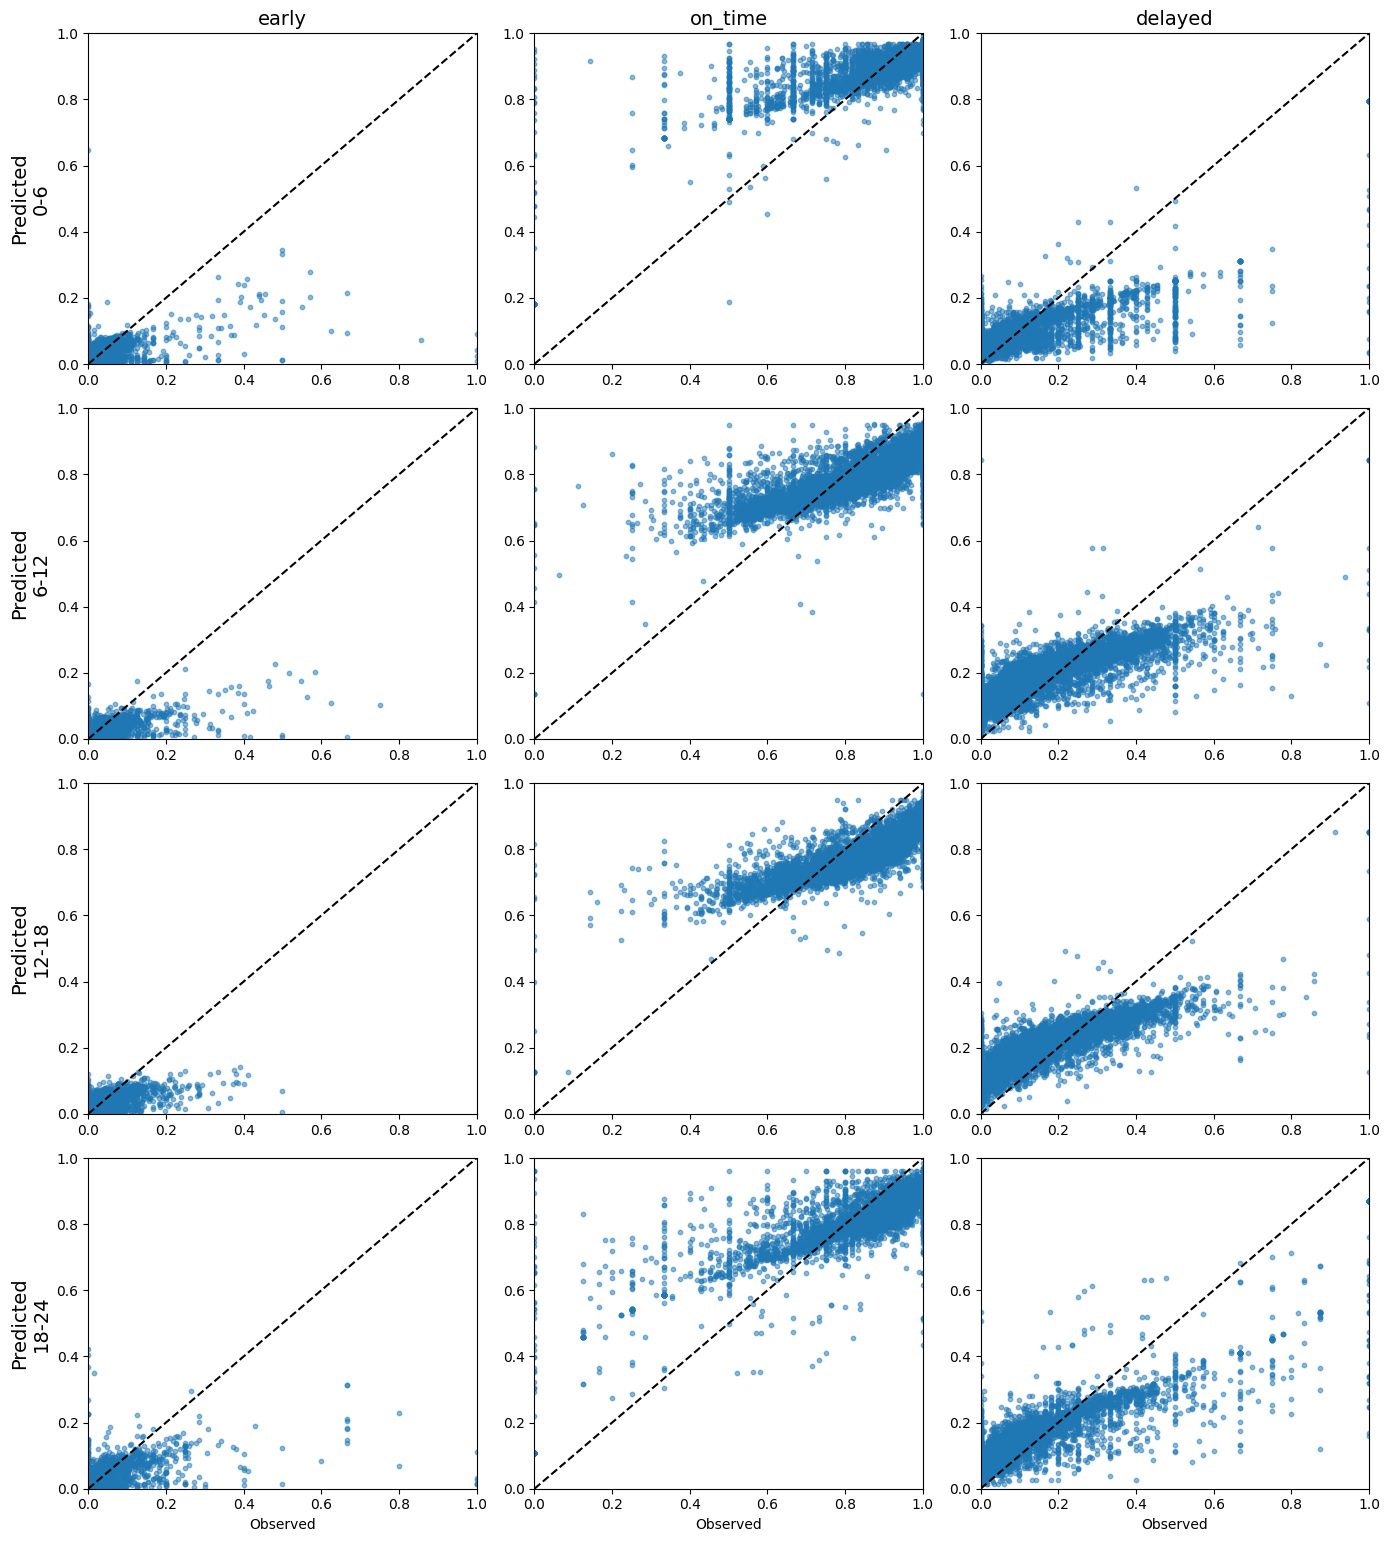

In [34]:
timebins = list(results.keys())

# Setup the subplots for the observed vs. predicted scatter plots for each time bin
# and each part of the composition.
fig, axes = plt.subplots(len(timebins), 3, figsize=(14, 4 * len(timebins)))

for r, tb in enumerate(timebins):
    res = results[tb]
    df_bin = res["df"]
    keep_idx = res["keep_idx"]

    fitted_Z_cent = res["fitted_Z_cent"]

    # Again construct the predicted compositions for the centrality-augmented model
    # by backtransforming the fitted values.
    Y_hat_cent = reconstruct_compositions(
        fitted_Z=fitted_Z_cent,
        bus_comp_grouped=df_bin,
        bus_comp_sar=df_bin,
        keep_idx=keep_idx
    )

    for c, p in enumerate(parts):
        # Plot the observed vs. predicted values for the part and time bin in the respective subplot.
        ax = axes[r, c]
        ax.scatter(df_bin[p], Y_hat_cent[:, c], alpha=0.5, s=10)
        ax.plot([0,1],[0,1], ls="--", color="black")
        ax.set_xlim(0,1)
        ax.set_ylim(0,1)
        # Only label the components for the first row and first column to avoid clutter.
        if r == 0:
            ax.set_title(p, fontsize=14)
        if c == 0:
            ax.set_ylabel(f"Predicted\n{tb}", fontsize=14)
        if r == len(timebins)-1:
            ax.set_xlabel("Observed")

plt.tight_layout(rect=[0,0,1,0.97])

plt.show()

### Moran's I and LISA for each timebin

In [35]:
lisa_results = {}

for tb, res in results.items():
    df_bin = res["df"]
    models_bin = res["models_cent"]
    W_cent = res["W_cent"]
    keep_idx = res["keep_idx"]

    print(f"\nMoran's I for time bin {tb}")

    # Yield the residuals for the centrality augmented model.
    res_ilr = [m.u.flatten() for m in models_bin]

    # For each ilr-coordinatem caluclate Moran's I like before.
    for k, r in enumerate(res_ilr):
        mi = Moran(r, W_cent, permutations=999)
        print(f"[{tb}] ILR{k+1}: Moran’s I={mi.I:.3f}, p={mi.p_sim:.4f}")

    # Perform LISA on the second ilr coordinate.
    k = 1 # Choose the ilr-coordinate.
    r = res_ilr[k]
    df_geo = df_bin.iloc[keep_idx].copy().reset_index(drop=True)

    # Build the corresponding geodataframe.
    gdf = gpd.GeoDataFrame(df_geo, geometry=gpd.points_from_xy(df_geo.stop_lon, df_geo.stop_lat), crs="EPSG:4326")

    # Perform a local Moran's I analysis and extract the labels and metrics.
    # Extract the custom severity as before.
    lisa = Moran_Local(r, W_cent, permutations=999)
    gdf["residual_ilr"] = r
    gdf["local_I"] = lisa.Is
    gdf["p_value"] = lisa.p_sim
    gdf["cluster"] = lisa.q
    gdf["is_significant"] = gdf["p_value"] < 0.05
    gdf["is_problem"] = gdf["cluster"] == 2
    gdf["hybrid_score"] = (
        gdf["is_significant"].astype(int)
        * gdf["is_problem"].astype(int)
        * gdf["local_I"].abs()
        * gdf["residual_ilr"].abs()
    )

    lisa_results[tb] = gdf


Moran's I for time bin 0-6
[0-6] ILR1: Moran’s I=0.062, p=0.0010
[0-6] ILR2: Moran’s I=0.175, p=0.0010

Moran's I for time bin 6-12
[6-12] ILR1: Moran’s I=0.038, p=0.0010
[6-12] ILR2: Moran’s I=0.191, p=0.0010

Moran's I for time bin 12-18
[12-18] ILR1: Moran’s I=0.009, p=0.1340
[12-18] ILR2: Moran’s I=0.201, p=0.0010

Moran's I for time bin 18-24
[18-24] ILR1: Moran’s I=-0.058, p=0.0010
[18-24] ILR2: Moran’s I=0.164, p=0.0010


In [36]:
# Get a summarized overview of the estimated parameters for each time bin and model in a single table.
rows = []
for tb, res in results.items():
    for k in range(2):
        m_base = res["models_base"][k]
        m_cent = res["models_cent"][k]

        rows.append({
            "time_bin": tb,
            "ilr": f"ILR{k+1}",
            "rho_base": m_base.rho,
            "rho_cent": m_cent.rho,
            "bet_cent": m_cent.betas.flatten()[1],
            "bet_p": m_cent.z_stat[1][1],
            "eig_cent": m_cent.betas.flatten()[2],
            "eig_p": m_cent.z_stat[2][1],
        })
param_df = pd.DataFrame(rows)
param_df

,time_bin,ilr,rho_base,rho_cent,bet_cent,bet_p,eig_cent,eig_p
0,0-6,ILR1,0.609006,0.609006,0.018700,0.000515,-1.895937,3.252027e-03
1,0-6,ILR2,0.609006,0.609006,-0.025636,0.001371,2.347089,1.427172e-02
2,6-12,ILR1,0.581209,0.581209,0.021779,0.000116,0.247267,6.148377e-01
3,6-12,ILR2,0.581209,0.581209,0.004147,0.524909,2.440560,1.742189e-05
4,12-18,ILR1,0.585148,0.585148,0.023022,0.000042,-0.318663,5.157028e-01
5,12-18,ILR2,0.585148,0.585148,0.017545,0.001907,3.159600,1.648819e-10
6,18-24,ILR1,0.642186,0.642186,0.016493,0.008659,-1.714034,1.799678e-01
7,18-24,ILR2,0.642186,0.642186,-0.003114,0.664435,1.098912,4.518215e-01


### Model Selection Metrics along the Time Bins

In [37]:
# Output the model selection results for the different time bins.
rows = []
for tb, res in results.items():
    models_base = res["models_base"]
    models_cent = res["models_cent"]
    for k in range(2):
        rows.append({
            "time_bin": tb,
            "ILR": f"ilr{k+1}",
            # Pseudo R²
            "R2_baseline": pseudo_r2(models_base[k]),
            "R2_centrality": pseudo_r2(models_cent[k]),
            # AIC
            "AIC_baseline": models_base[k].aic,
            "AIC_centrality": models_cent[k].aic,
            # optional: log-likelihood
            "LL_baseline": models_base[k].logll,
            "LL_centrality": models_cent[k].logll,
        })
eval_timebins = pd.DataFrame(rows)
eval_timebins

,time_bin,ILR,R2_baseline,R2_centrality,AIC_baseline,AIC_centrality,LL_baseline,LL_centrality
0,0-6,ilr1,0.655620,0.655503,17556.925836,17540.170473,-8776.462918,-8766.085236
1,0-6,ilr2,0.695853,0.694734,24958.468158,24946.196488,-12477.234079,-12469.098244
2,6-12,ilr1,0.580742,0.581335,21907.369062,21896.187163,-10951.684531,-10944.093581
3,6-12,ilr2,0.691933,0.691059,25028.777383,25013.801545,-12512.388692,-12502.900773
4,12-18,ilr1,0.556814,0.557315,21474.249644,21461.130073,-10735.124822,-10726.565037
5,12-18,ilr2,0.710428,0.708116,21635.175948,21587.939160,-10815.587974,-10789.969580
6,18-24,ilr1,0.603963,0.604275,17033.269570,17028.642123,-8514.634785,-8510.321061
7,18-24,ilr2,0.749127,0.749041,19122.322989,19125.574306,-9559.161494,-9558.787153


### Anomaly Recurrance across Time Bins

In [38]:
# Extract the LH-cluster for each time bin.
lh_by_bin = {}

for tb, gdf in lisa_results.items():
    lh = gdf[
        (gdf["cluster"] == 2) &    # Low–High
        (gdf["p_value"] < 0.05)
    ][["station_id", "stop_name"]].copy()
    lh_by_bin[tb] = lh
    print(f"{tb}: {len(lh)} Low–High stations")

# Create a unified table of the LH-clusters across all time bins.
lh_long = []
for tb, df in lh_by_bin.items():
    tmp = df[["station_id", "stop_name"]].copy()
    tmp["time_bin"] = tb
    lh_long.append(tmp)
lh_long = pd.concat(lh_long, ignore_index=True)

# Group by stations and count in how many time bins they are part of a signignificant LH-cluster.
persistent_2plus = (
    lh_long
    .groupby(["station_id", "stop_name"])
    .agg(n_bins=("time_bin", "nunique"))
    .query("n_bins >= 2")
    .reset_index()
)

# Sort the values to see the most persistently delyed stations at the top.
persistent_2plus.sort_values("n_bins", ascending=False).head(10)

0-6: 150 Low–High stations
6-12: 140 Low–High stations
12-18: 189 Low–High stations
18-24: 149 Low–High stations


,station_id,stop_name,n_bins
18,900360000,"Frankfurt (Oder), Bahnhof",3
20,900360070,"Frankfurt (Oder), Kieler Str.",3
25,900360152,"Frankfurt (Oder), Ziolkowskiallee",2
19,900360035,"Frankfurt (Oder), Bruno-Peters-Berg",2
21,900360075,"Frankfurt (Oder), Kliestow Rohrpfuhl",2
22,900360094,"Frankfurt (Oder), Carthausplatz",2
23,900360097,"Frankfurt (Oder), Messegelände",2
24,900360111,"Frankfurt (Oder), Perleberger Str.",2
0,900100001,S+U Friedrichstr. Bhf (Berlin),2
1,900142502,"Berlin, Alt-Blankenburg",2


### Pain-Points with Severity across Time Bins

In [39]:
# Set up the norm for the colour scale of the hybrid score.
norm = Normalize(
    vmin=0,
    vmax=max(
        gdf["hybrid_score"].quantile(0.95)
        for gdf in lisa_results.values()
        if (gdf["hybrid_score"] > 0).any()
    )
)

def plot_LH_timebins(lisa_results, time_bins, title="Pain-Points for ilr2 across time bins"):
    # Set up the subplots.
    fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
    axes = axes.flatten()
    for ax, tb in zip(axes, time_bins):
        gdf = lisa_results[tb]
        # Set up the background scatterplot of all stations
        ax.scatter(gdf.geometry.x, gdf.geometry.y, s=6, color="lightgrey")
        # Extract the significant LH-clusters with the hybrid score.
        lh = gdf[
            (gdf["cluster"] == 2) &
            (gdf["p_value"] < 0.05) &
            (gdf["hybrid_score"] > 0)
        ]
        # Overlay the pain-points with a colour scale based on the hybrid score.
        sc = ax.scatter(lh.geometry.x, lh.geometry.y, s=40, c=lh["hybrid_score"],
                        cmap=cmap, norm=norm, edgecolor="black", linewidth=0.3)
        ax.set_title(f"Time bin: {tb}")
        ax.set_xticks([])
        ax.set_yticks([])
        # Include the number of pain-points.
        ax.text(0.02, 0.02, f"# of pain-points = {len(lh)}", transform=ax.transAxes, fontsize=9,
                verticalalignment="bottom")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    return fig

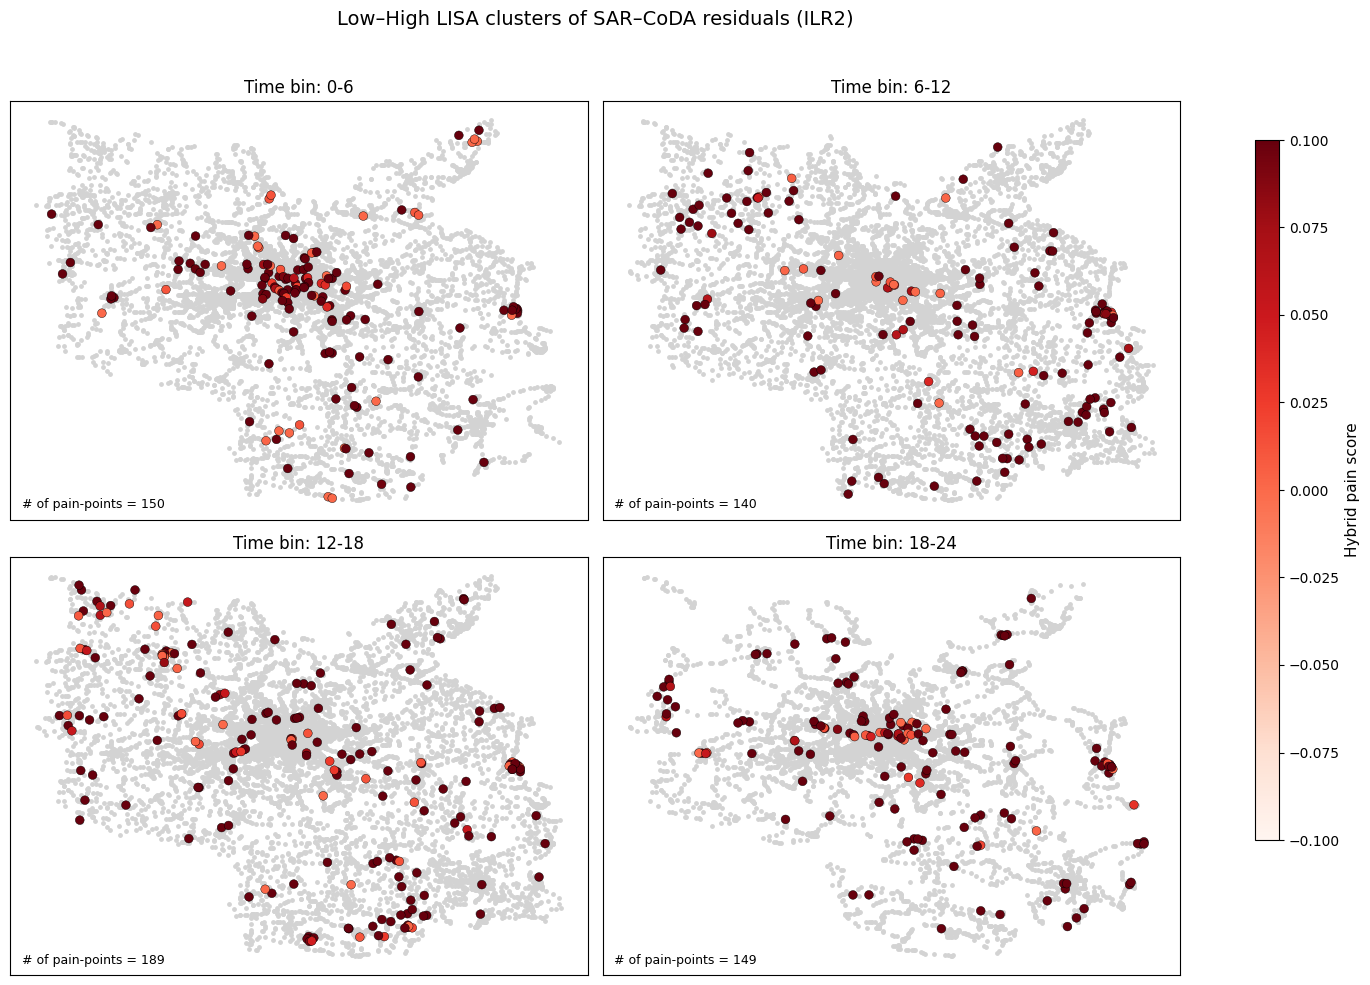

In [40]:
# Set up the maps for the hybrid score.
cmap = plt.cm.Reds
fig = plot_LH_timebins(lisa_results=lisa_results, time_bins=TIME_BINS,
                       title="Low–High LISA clusters of SAR–CoDA residuals (ILR2)")
# Add the colourbar.
cax = fig.add_axes([1.05, 0.15, 0.02, 0.7])
cb = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), cax=cax)
cb.set_label("Hybrid pain score", fontsize=11)

plt.show()